## Gender Word Ratio Analysis Notebook

This notebook uses the data from the XXXX.py script, and cannot be run without it. 

### 1. Importing Data 

Import the csv file that was saved at the end of the aforementioned script.

NB: If you are using an environment, please remember to choose kernel accordingly


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import ttest_ind, mannwhitneyu, levene
from statsmodels.stats.proportion import proportions_ztest
import os

# --- Load the enriched gender word count dataset ---
df_gcw = pd.read_csv("stats_outputs/df_genderword_analysis.csv")

### Gendered Word Ratio Analysis

To unequal groups, the ratio is used rather than the raw count of gendered words. This Ratio was calculated in the previous script. 

=== Summary: Gendered Word Ratio ===
             count      mean       std  min       25%       50%       75%  \
group                                                                       
2022       14617.0  0.066209  0.026295  0.0  0.049180  0.061983  0.078431   
2024/2025  10051.0  0.068522  0.025560  0.0  0.050802  0.063529  0.081676   

                max  
group                
2022       0.360000  
2024/2025  0.285714  

=== Share of Ads with Any Gendered Words ===
2022: 14585/14617 (99.8%) contain gendered words
2024/2025: 10046/10051 (100.0%) contain gendered words


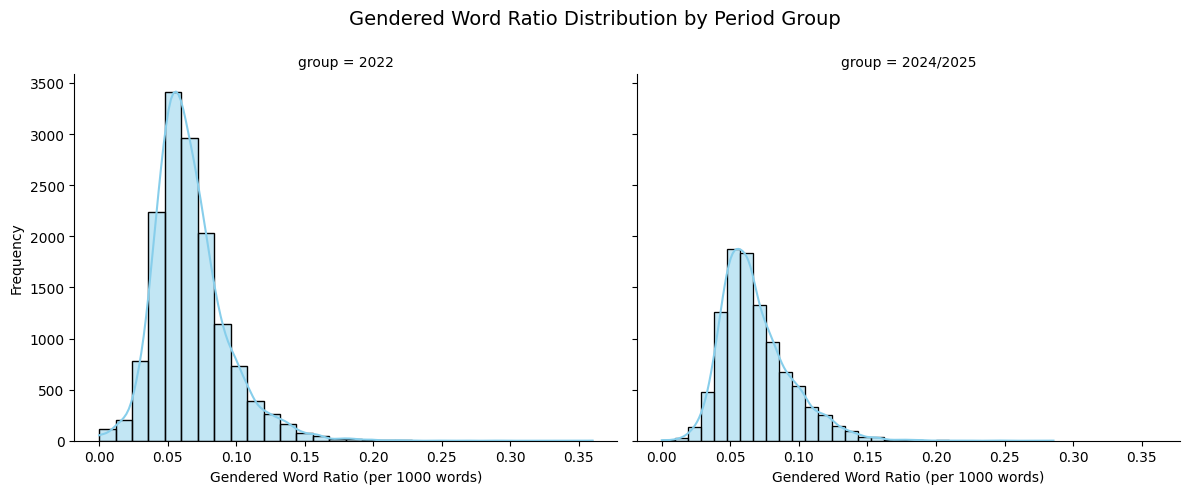

Plot saved to 'plot_outputs/gendered_word_ratio_distribution_by_period_group.png'


In [19]:
# Create output directory
output_plot_dir = "plot_outputs"
os.makedirs(output_plot_dir, exist_ok=True)

# --- Summary statistics for gendered_ratio ---
print("=== Summary: Gendered Word Ratio ===")
print(df_gcw.groupby("group")["gendered_ratio"].describe())

# --- Proportion of ads containing any gendered words ---
print("\n=== Share of Ads with Any Gendered Words ===")
for group in ["2022", "2024/2025"]:
    n = len(df_gcw[df_gcw["group"] == group])
    has_any = (df_gcw[df_gcw["group"] == group]["gendered_word_count"] > 0).sum()
    print(f"{group}: {has_any}/{n} ({100*has_any/n:.1f}%) contain gendered words")

# --- Faceted histogram of gendered_ratio ---
g = sns.FacetGrid(
    df_gcw,
    col="group",
    col_order=["2022", "2024/2025"],
    height=5,
    aspect=1.2,
    sharex=True,
    sharey=True
)
g.map(sns.histplot, "gendered_ratio", bins=30, kde=True, color="skyblue")
g.set_axis_labels("Gendered Word Ratio (per 1000 words)", "Frequency")
g.fig.subplots_adjust(top=0.85)
g.fig.suptitle("Gendered Word Ratio Distribution by Period Group", fontsize=14)
output_path_ = os.path.join(output_plot_dir, "gendered_word_ratio_distribution_by_period_group.png")
plt.savefig(output_path_, dpi=300)
plt.show()
print(f"Plot saved to '{output_path_}'")

### Q-Q Plots

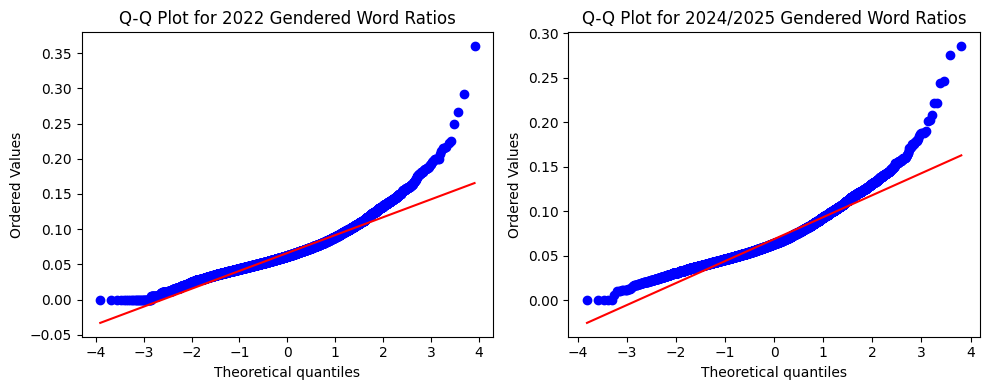

In [20]:
# --- Q-Q plots ---
plt.figure(figsize=(10, 4))
for i, group in enumerate(["2022", "2024/2025"], 1):
    plt.subplot(1, 2, i)
    data = df_gcw[df_gcw["group"] == group]["gendered_ratio"]
    stats.probplot(data, dist="norm", plot=plt)
    plt.title(f"Q-Q Plot for {group} Gendered Word Ratios")
plt.tight_layout()
plt.show()

### Boxplot

/var/folders/wb/6mdx7sq923sft6mn64xx6b600000gn/T/ipykernel_12904/1132748000.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


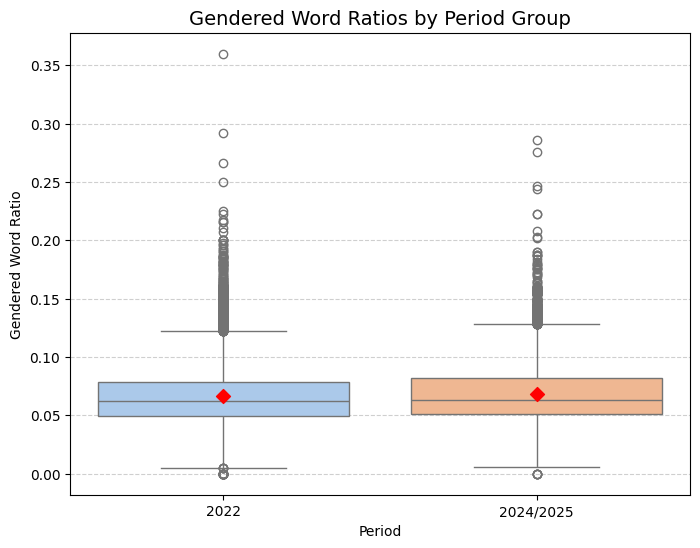

Boxplot saved to: plot_outputs/gendered_word_ratio_by_period_group_boxplot.png


In [21]:
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=df_gcw,
    x='group',
    y='gendered_ratio',
    order=["2022", "2024/2025"],
    palette='pastel'
)
plt.grid(axis='y', linestyle='--', alpha=0.6)
means = df_gcw.groupby("group")["gendered_ratio"].mean()
for i, period in enumerate(["2022", "2024/2025"]):
    plt.scatter(i, means[period], color='red', zorder=10, marker='D', s=50)
plt.title("Gendered Word Ratios by Period Group", fontsize=14)
plt.xlabel("Period")
plt.ylabel("Gendered Word Ratio")
output_path = os.path.join(output_plot_dir, "gendered_word_ratio_by_period_group_boxplot.png")
plt.savefig(output_path, dpi=300)
plt.show()
print(f"Boxplot saved to: {output_path}")

### Levene's, Proportion Z-test, Welch's T-test, and Mann-Whitney U, Cohen's d

In [22]:
# --- Group filtering ---
group_2022 = df_gcw[df_gcw["group"] == "2022"]
group_recent = df_gcw[df_gcw["group"] == "2024/2025"]
intensity_2022 = group_2022[group_2022["gendered_ratio"] > 0]["gendered_ratio"]
intensity_recent = group_recent[group_recent["gendered_ratio"] > 0]["gendered_ratio"]

# --- Statistical tests: gendered_ratio ---
lev_stat, lev_p = levene(intensity_2022, intensity_recent)
print(f"\nLevene's test: W = {lev_stat:.3f}, p = {lev_p:.4f}")

# successes = [
#     (group_2022["gendered_word_count"] > 0).sum(),
#     (group_recent["gendered_word_count"] > 0).sum()
# ]
# nobs = [len(group_2022), len(group_recent)]
# z_stat, z_p = proportions_ztest(successes, nobs)
# print(f"Proportion Z-test: z = {z_stat:.3f}, p = {z_p:.4f}")

t_stat, t_p = ttest_ind(intensity_recent, intensity_2022, equal_var=False)
print(f"Welch's t-test: t = {t_stat:.3f}, p = {t_p:.4f}")

u_stat, u_p = mannwhitneyu(intensity_recent, intensity_2022, alternative='two-sided')
print(f"Mann-Whitney U test: U = {u_stat}, p = {u_p:.4f}")

def cohens_d(a, b):
    diff = np.mean(a) - np.mean(b)
    pooled_sd = np.sqrt(((np.std(a, ddof=1) ** 2 + np.std(b, ddof=1) ** 2) / 2))
    return diff / pooled_sd
d = cohens_d(intensity_recent, intensity_2022)
print(f"Cohen's d: {d:.3f}")


Levene's test: W = 0.012, p = 0.9145
Welch's t-test: t = 6.589, p = 0.0000
Mann-Whitney U test: U = 76935871.0, p = 0.0000
Cohen's d: 0.085


### Gender Bias Score


=== Summary: Gender Bias Score (Feminine - Masculine) ===
             count       mean        std    min   25%   50%  75%   max
group                                                                 
2022       14617.0 -13.182390  14.354006 -150.0 -20.0 -11.0 -4.0  41.0
2024/2025  10051.0 -15.761317  16.063234 -204.0 -23.0 -14.0 -5.0  41.0


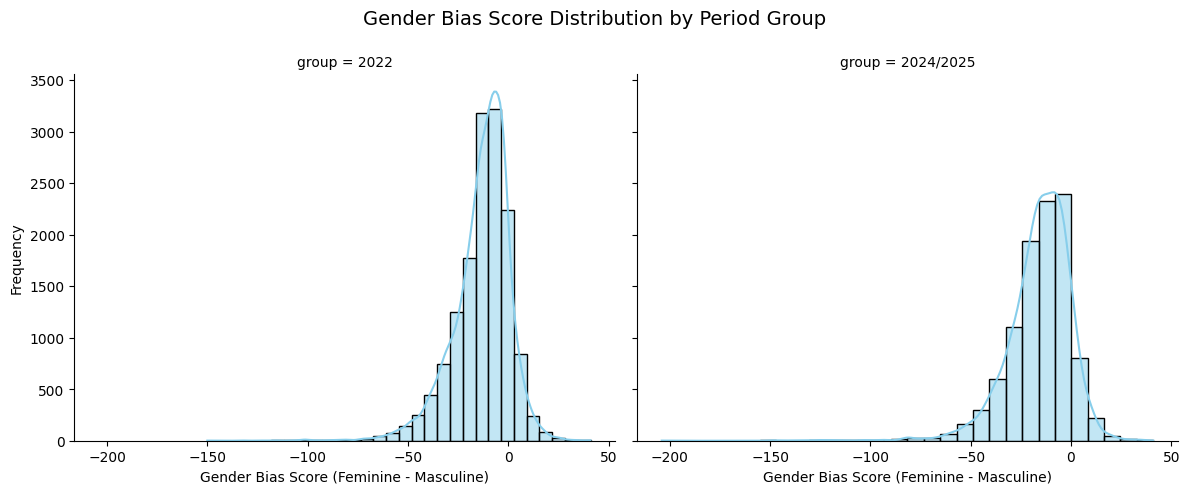

Faceted histogram saved to: plot_outputs/gender_bias_score_distribution_by_period_group.png


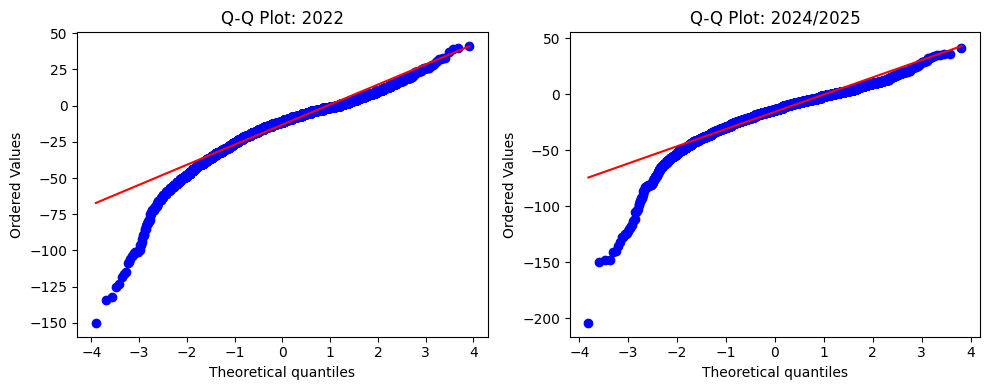

Q-Q plots saved to: plot_outputs/gender_bias_score_qq_plots.png


/var/folders/wb/6mdx7sq923sft6mn64xx6b600000gn/T/ipykernel_12904/4008057883.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


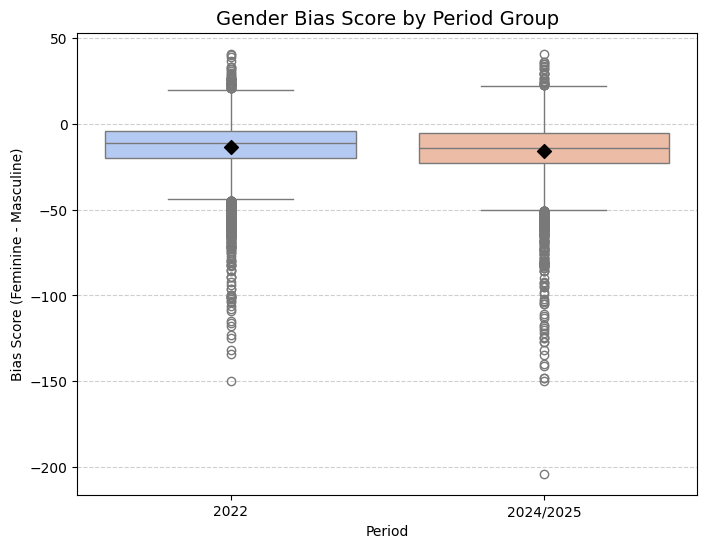

Bias Score Boxplot saved to: plot_outputs/gender_bias_score_by_period_group_boxplot.png
Levene's test on Bias Score: W = 69.479, p = 0.0000
Welch's t-test on Bias Score: t = -12.932, p = 0.0000
Mann-Whitney U test on Bias Score: U = 65739875.5, p = 0.0000
Cohen's d (Bias Score): -0.169


In [23]:
# ================================
# === Gender Bias Score Analysis
# ================================

# --- Summary statistics ---
print("\n=== Summary: Gender Bias Score (Feminine - Masculine) ===")
print(df_gcw.groupby("group")["gender_bias_score"].describe())

# --- Faceted histogram for gender_bias_score (matching style) ---
g = sns.FacetGrid(
    df_gcw,
    col="group",
    col_order=["2022", "2024/2025"],
    height=5,
    aspect=1.2,
    sharex=True,
    sharey=True
)
g.map(sns.histplot, "gender_bias_score", bins=30, kde=True, color="skyblue")
g.set_axis_labels("Gender Bias Score (Feminine - Masculine)", "Frequency")
g.fig.subplots_adjust(top=0.85)
g.fig.suptitle("Gender Bias Score Distribution by Period Group", fontsize=14)

# Save plot
output_path_bias_hist = os.path.join(output_plot_dir, "gender_bias_score_distribution_by_period_group.png")
plt.savefig(output_path_bias_hist, dpi=300)
plt.show()
print(f"Faceted histogram saved to: {output_path_bias_hist}")


# --- Q-Q plots by group ---
plt.figure(figsize=(10, 4))
for i, group in enumerate(["2022", "2024/2025"], 1):
    plt.subplot(1, 2, i)
    data = df_gcw[df_gcw["group"] == group]["gender_bias_score"]
    stats.probplot(data, dist="norm", plot=plt)
    plt.title(f"Q-Q Plot: {group}")
plt.tight_layout()
output_path_qq = os.path.join(output_plot_dir, "gender_bias_score_qq_plots.png")
plt.savefig(output_path_qq, dpi=300)
plt.show()
print(f"Q-Q plots saved to: {output_path_qq}")

# --- Boxplot with means ---
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=df_gcw,
    x='group',
    y='gender_bias_score',
    order=["2022", "2024/2025"],
    palette='coolwarm'
)
plt.grid(axis='y', linestyle='--', alpha=0.6)
means = df_gcw.groupby("group")["gender_bias_score"].mean()
for i, period in enumerate(["2022", "2024/2025"]):
    plt.scatter(i, means[period], color='black', zorder=10, marker='D', s=50)
plt.title("Gender Bias Score by Period Group", fontsize=14)
plt.xlabel("Period")
plt.ylabel("Bias Score (Feminine - Masculine)")
output_path_bias = os.path.join(output_plot_dir, "gender_bias_score_by_period_group_boxplot.png")
plt.savefig(output_path_bias, dpi=300)
plt.show()
print(f"Bias Score Boxplot saved to: {output_path_bias}")

# --- Levene’s Test (equality of variance) ---
from scipy.stats import levene

lev_stat_b, lev_p_b = levene(bias_recent, bias_2022)
print(f"Levene's test on Bias Score: W = {lev_stat_b:.3f}, p = {lev_p_b:.4f}")


# --- Welch's T-test ---
bias_2022 = df_gcw[df_gcw["group"] == "2022"]["gender_bias_score"]
bias_recent = df_gcw[df_gcw["group"] == "2024/2025"]["gender_bias_score"]
t_stat_b, t_p_b = ttest_ind(bias_recent, bias_2022, equal_var=False)
print(f"Welch's t-test on Bias Score: t = {t_stat_b:.3f}, p = {t_p_b:.4f}")

# --- Mann-Whitney U ---
u_stat_b, u_p_b = mannwhitneyu(bias_recent, bias_2022, alternative='two-sided')
print(f"Mann-Whitney U test on Bias Score: U = {u_stat_b}, p = {u_p_b:.4f}")

# --- Cohen's D ---
def cohens_d(a, b):
    diff = np.mean(a) - np.mean(b)
    pooled_sd = np.sqrt(((np.std(a, ddof=1) ** 2 + np.std(b, ddof=1) ** 2) / 2))
    return diff / pooled_sd

d_bias = cohens_d(bias_recent, bias_2022)
print(f"Cohen's d (Bias Score): {d_bias:.3f}")
